# BIRCH - H&M (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    birch_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/hym_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/hym_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["customer_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 1,362,281
Variables de clustering: 3


,recency,frequency,monetary
0,-1.216313,0.926194,0.765377
1,-0.614156,1.811026,1.771317
2,-1.404203,0.565013,0.847795
3,1.106440,-1.007279,-1.056769
4,-0.918963,0.413566,0.433500


## Evaluación del número de clusters


In [3]:
resultados_birch = birch_metrics(X)
display(resultados_birch)

C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


,k,silhouette,calinski_harabasz,davies_bouldin,n_clusters_found,tiempo_segundos
0,2,0.482675,1.681837e+06,0.713841,2,11.338001
1,3,0.378598,1.491546e+06,0.966151,3,9.970278
2,4,0.317324,1.369231e+06,1.035162,4,9.970275
3,5,0.349856,1.290308e+06,0.905355,5,9.967642
4,6,0.354335,1.313564e+06,0.906958,6,9.963567
5,7,0.315533,1.312336e+06,1.082805,7,9.975277
6,8,0.319541,1.066531e+06,0.954509,8,9.981799
7,9,0.306683,1.074484e+06,1.070110,9,9.985800
8,10,0.292791,1.150286e+06,0.993860,10,9.978321


In [4]:
tabla_metricas = save_clustering_metrics(
    resultados_birch,
    model_name="birch",
    dataset_name="hym",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

Métricas consolidadas en ../../../results/clustering_metrics.csv


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,minibatch,instacart,simple,6,0.287861,92542.785246,1.110500,191238.961903,0.476716,NaN,NaN,NaN,NaN,NaN,NaN
248,minibatch,instacart,simple,7,0.287363,88688.845444,1.083745,173472.413504,0.090507,NaN,NaN,NaN,NaN,NaN,NaN
249,minibatch,instacart,simple,8,0.284887,90539.561492,1.089686,152061.334109,0.358054,NaN,NaN,NaN,NaN,NaN,NaN
250,minibatch,instacart,simple,9,0.282639,87440.639855,1.070433,140993.880428,0.330287,NaN,NaN,NaN,NaN,NaN,NaN


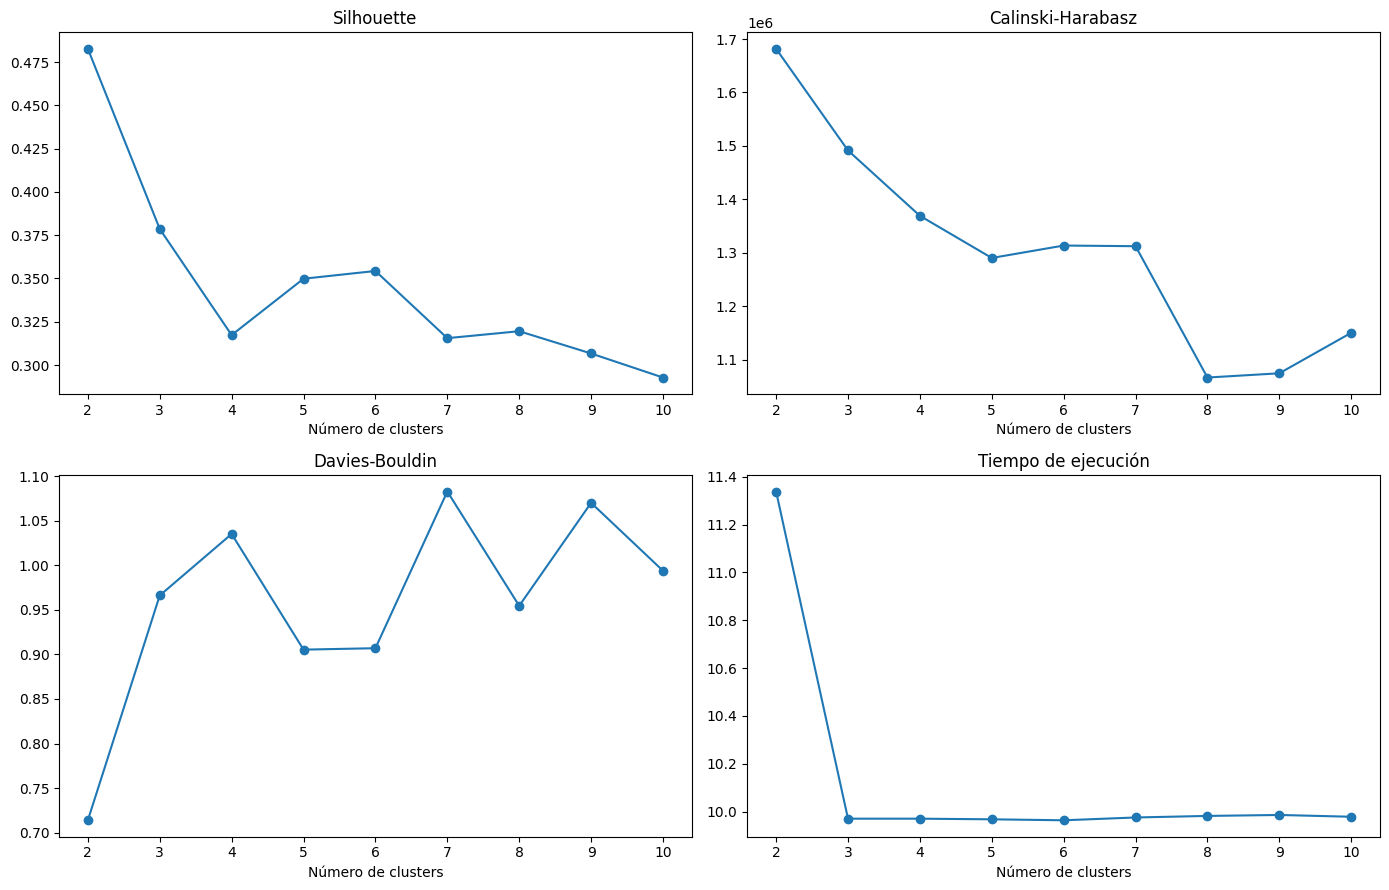

In [5]:
plot_clustering_metrics(
    resultados_birch,
    fourth_metric="tiempo_segundos",
    fourth_title="Tiempo de ejecución",
)

## Ajuste final y perfil de los clusters


In [6]:
modelo, labels = fit_clustering_model(
    model_name="birch",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="customer_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

C:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


Tamaño de los clusters:


cluster
0    964319
1    397962
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    70.79
1    29.21
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,monetary
cluster,,,
0,307.725,2.421,0.202
1,62.708,16.949,1.732


- Cluster 0 - Clientes ocasionales y de bajo valor (70,79%): muestran una recencia alta, una frecuencia de apenas 2,42 compras y un gasto reducido. Constituyen el segmento mayoritario con menor vinculación comercial.
- Cluster 1 - Clientes activos y de alto valor (29,21%): presentan una recencia muy inferior, cerca de 17 compras y un gasto notablemente mayor. Son los clientes más recurrentes y valiosos.